已知
向量 a = [2, -1, 3]^T，b = [1, 4, -2]^T
矩阵
A = [[-1, 0, 2],
   [1, 3, 1]]
B = [[2, 1],
   [0, 3],
   [2, -1]]

向量点积 a·b
a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8

矩阵乘法 A×B（结果矩阵的形状？）
A 的形状为 2×3，B 的形状为 3×2，故乘积 C = A×B 的形状为 2×2。
计算过程：
C[1,1] = (-1)×2 + 0×0 + 2×2 = 2
C[1,2] = (-1)×1 + 0×3 + 2×(-1) = -3
C[2,1] = 1×2 + 3×0 + 1×2 = 4
C[2,2] = 1×1 + 3×3 + 1×(-1) = 9
所以 C = [[2, -3], [4, 9]]

向量 a 的 Frobenius 范数
‖a‖_F = √(2² + (-1)² + 3²) = √(4 + 1 + 9) = √14

In [2]:
import numpy as np

# 1. 创建形状为 3×4 的随机矩阵 X，服从标准正态分布
X = np.random.randn(3, 4)
print("X =\n", X)

# 2. 创建形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\nY =\n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = X @ Y
print("\nZ = X × Y =\n", Z)

# 4. 输出 Z 的第一行第二列交叉处元素，以及第 2 行所有元素
element = Z[0, 1]      # 第一行、第二列
second_row = Z[1, :]   # 第二行（索引1）
print("\nZ 中第一行第二列元素:", element)
print("Z 的第二行所有元素:", second_row)

# 5. 计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z, 'fro')
print("\nZ 的 Frobenius 范数:", frob_norm)

X =
 [[-0.3305082   1.61557872  1.04771145 -1.38756504]
 [-1.32086125  1.79715002 -1.97933603  0.13428811]
 [-0.13784668  0.13120725  0.05305545 -0.77571765]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X × Y =
 [[ 0.94521694  0.94521694]
 [-1.36875915 -1.36875915]
 [-0.72930163 -0.72930163]]

Z 中第一行第二列元素: 0.9452169388337297
Z 的第二行所有元素: [-1.36875915 -1.36875915]

Z 的 Frobenius 范数: 2.5685862062557416


某疾病在人群中的患病率为 0.1%（即 P(D)=0.001）。检验方法：

若患病，阳性概率 P(+|D)=0.99（灵敏度）

若未患病，阳性概率 P(+|¬D)=0.02（假阳性率）

一个人检验结果为阳性，求其真正患病的概率 P(D|+)。

由贝叶斯公式：
P(D|+) = P(+|D)·P(D) / [P(+|D)·P(D) + P(+|¬D)·P(¬D)]
代入数值：
P(D|+) = (0.99 × 0.001) / (0.99 × 0.001 + 0.02 × 0.999)
    = 0.00099 / (0.00099 + 0.01998)
    = 0.00099 / 0.02097
    ≈ 0.0472

所以患病概率约为 4.72%。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000   # 每次抽样的样本量
m = 1000    # 重复次数

# 生成 m 次样本均值
means = np.mean(np.random.uniform(0, 1, size=(m, n)), axis=1)

# 绘制直方图
plt.figure(figsize=(8,5))
plt.hist(means, bins=40, density=True, alpha=0.6, color='g', label='Sample means')

# 理论正态分布
mu_true = 0.5
sigma_true = np.sqrt(1/12 / n)
x = np.linspace(mu_true - 4*sigma_true, mu_true + 4*sigma_true, 200)
plt.plot(x, norm.pdf(x, mu_true, sigma_true), 'r-', lw=2, label='Theoretical normal')

plt.title(f'Central Limit Theorem (Uniform(0,1), n={n})')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.show()

# 计算实际方差
actual_var = np.var(means, ddof=0)
print("实际方差 (ddof=0):", actual_var)
print("理论方差 (1/(12n)):", 1/(12*n))

<Figure size 800x500 with 1 Axes>

实际方差 (ddof=0): 7.758894757278165e-06
理论方差 (1/(12n)): 8.333333333333334e-06


给定函数 z = (w1·x1 + w2·x2 - y)²，其中 x1=2, x2=1, y=3 为常数，w1,w2 为变量。

偏导数表达式
令 u = w1·x1 + w2·x2 - y = 2w1 + w2 - 3，则 z = u²。
∂z/∂w1 = 2u · ∂u/∂w1 = 2(2w1 + w2 - 3) × 2 = 4(2w1 + w2 - 3)
∂z/∂w2 = 2u · ∂u/∂w2 = 2(2w1 + w2 - 3) × 1 = 2(2w1 + w2 - 3)

当 w1=0.5, w2=1 时的梯度值
u = 2×0.5 + 1 - 3 = -1
∂z/∂w1 = 4 × (-1) = -4
∂z/∂w2 = 2 × (-1) = -2

In [4]:
import torch

# 1. 前向计算（手动数值）
x_val, w1_val, w2_val = 2.0, 1.5, 0.5
a_val = x_val * w1_val
b_val = a_val + w2_val
L_val = b_val ** 2
print("前向结果：a =", a_val, ", b =", b_val, ", L =", L_val)

# 2. 手动反向传播（链式法则）
dL_db = 2 * b_val
dL_dw2 = dL_db * 1         # db/dw2 = 1
dL_da = dL_db * 1          # db/da = 1
dL_dw1 = dL_da * x_val     # da/dw1 = x
print("\n手动梯度：dL/dw1 =", dL_dw1, ", dL/dw2 =", dL_dw2)

# 3. 使用 PyTorch 自动微分验证
x = torch.tensor(x_val, requires_grad=False)
w1 = torch.tensor(w1_val, requires_grad=True)
w2 = torch.tensor(w2_val, requires_grad=True)

a = x * w1
b = a + w2
L = b**2
L.backward()
print("PyTorch 梯度：w1.grad =", w1.grad.item(), ", w2.grad =", w2.grad.item())
print("结果一致：", torch.allclose(w1.grad, torch.tensor(dL_dw1))
      and torch.allclose(w2.grad, torch.tensor(dL_dw2)))

前向结果：a = 3.0 , b = 3.5 , L = 12.25

手动梯度：dL/dw1 = 14.0 , dL/dw2 = 7.0
PyTorch 梯度：w1.grad = 14.0 , w2.grad = 7.0
结果一致： True


线性回归模型 y = w·x + b，均方误差损失
L = (1/n) Σ_i=1^n (y_i - (w·x_i + b))²

对 w 的偏导数：
∂L/∂w = (1/n) Σ_i=1^n 2·(y_i - w·x_i - b)·(-x_i) = -(2/n) Σ_i=1^n x_i·(y_i - w·x_i - b)

对 b 的偏导数：
∂L/∂b = (1/n) Σ_i=1^n 2·(y_i - w·x_i - b)·(-1) = -(2/n) Σ_i=1^n (y_i - w·x_i - b)

In [7]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载手写数字数据集（8×8图像，共10类）
digits = load_digits()
X = digits.images.reshape(-1, 64) / 16.0   # 展平并归一化到[0,1]
y = digits.target.reshape(-1, 1)

# 标签 one-hot 编码
# 注意：旧版本 sklearn 使用 sparse=False，新版本 (>=1.2) 使用 sparse_output=False
# 为兼容，先尝试 sparse_output=False，失败则用 sparse=False
try:
    encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(sparse=False)

y_onehot = encoder.fit_transform(y)    # shape: (n_samples, 10)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42)

# 参数初始化
n_features, n_classes = 64, 10
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-12)) / m

# 超参数
batch_size = 32
lr = 0.1
epochs = 50
n_train = X_train.shape[0]

# 训练循环
for epoch in range(epochs):
    idx = np.random.permutation(n_train)
    X_shuffled = X_train[idx]
    y_shuffled = y_train[idx]
    
    for i in range(0, n_train, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        scores = X_batch @ W + b
        probs = softmax(scores)
        
        # 梯度计算
        m_batch = X_batch.shape[0]
        d_scores = probs - y_batch       # softmax + 交叉熵的联合梯度
        dW = X_batch.T @ d_scores / m_batch
        db = np.sum(d_scores, axis=0, keepdims=True) / m_batch
        
        # 参数更新
        W -= lr * dW
        b -= lr * db

# 测试准确率
scores_test = X_test @ W + b
probs_test = softmax(scores_test)
y_pred = np.argmax(probs_test, axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred == y_true)
print(f"测试集准确率: {accuracy:.4f}")

c:\Users\12224\Anaconda3\lib\site-packages\sklearn\datasets\base.py:532: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  target = data[:, -1].astype(np.int)
c:\Users\12224\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:1961: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, chec

测试集准确率: 0.9583


假设样本 x₁, x₂, …, xₙ 独立同分布于正态分布 N(μ, σ²)。

似然函数
L(μ, σ²) = Π_{i=1}^n (1/√(2πσ²)) · exp( -(x_i - μ)² / (2σ²) )
    = (2πσ²)^{-n/2} · exp( -1/(2σ²) Σ_{i=1}^n (x_i - μ)² )

证明 μ 的最大似然估计为 μ̂ = (1/n) Σ x_i
取对数似然：ℓ = ln L = -(n/2)ln(2π) - (n/2)ln(σ²) - 1/(2σ²) Σ (x_i - μ)²
对 μ 求偏导：∂ℓ/∂μ = (1/σ²) Σ (x_i - μ) = 0
  → Σ x_i - nμ = 0 → μ̂ = (1/n) Σ x_i

证明 σ² 的最大似然估计为 σ̂² = (1/n) Σ (x_i - μ̂)²
对 σ² 求偏导（将 σ² 视为一个变量）：
∂ℓ/∂σ² = -n/(2σ²) + 1/(2(σ²)²) Σ (x_i - μ)² = 0 →
代入 μ = μ̂ 并整理： n/σ² = (1/σ⁴) Σ (x_i - μ̂)² → σ̂² = (1/n) Σ (x_i - μ̂)²

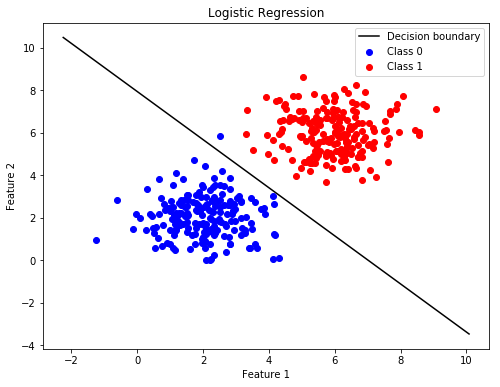

测试集准确率: 0.9800


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成二分类线性可分数据
np.random.seed(42)
n_per_class = 200
X0 = np.random.randn(n_per_class, 2) + np.array([2, 2])
y0 = np.zeros(n_per_class)
X1 = np.random.randn(n_per_class, 2) + np.array([6, 6])
y1 = np.ones(n_per_class)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1]).reshape(-1, 1)

# 打乱
idx = np.random.permutation(len(y))
X, y = X[idx], y[idx]

# 添加偏置列（对应截距 b）
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])  # 第一列全1

# 生成测试集（新100个样本）
X0_test = np.random.randn(50, 2) + np.array([2, 2])
X1_test = np.random.randn(50, 2) + np.array([6, 6])
X_test = np.vstack([X0_test, X1_test])
y_test = np.vstack([np.zeros((50, 1)), np.ones((50, 1))])
X_test_bias = np.hstack([np.ones((100, 1)), X_test])

# 2. 定义 sigmoid 和损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-12) +
                    (1 - y_true) * np.log(1 - y_pred + 1e-12))

# 3. 梯度下降训练
lr, iters = 0.1, 1000
theta = np.random.randn(3, 1) * 0.01   # [b, w1, w2]

for i in range(iters):
    z = X_bias @ theta
    h = sigmoid(z)
    gradient = (X_bias.T @ (h - y)) / len(y)
    theta -= lr * gradient

# 4. 绘制决策边界并评估
plt.figure(figsize=(8,6))
plt.scatter(X0[:,0], X0[:,1], c='blue', label='Class 0')
plt.scatter(X1[:,0], X1[:,1], c='red', label='Class 1')

# 决策边界：theta[0] + theta[1]*x1 + theta[2]*x2 = 0  => x2 = -(theta[0]+theta[1]*x1)/theta[2]
x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_vals = -(theta[0] + theta[1]*x1_vals) / theta[2]
plt.plot(x1_vals, x2_vals, 'k-', label='Decision boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression')
plt.show()

# 测试集准确率
z_test = X_test_bias @ theta
pred_test = sigmoid(z_test) >= 0.5
accuracy = np.mean(pred_test == y_test)
print(f"测试集准确率: {accuracy:.4f}")